In [1]:
import random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as T

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [2]:
transform = T.ToTensor()

full_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

# I ignored the labels entirely
all_indices = list(range(len(full_dataset)))
random.shuffle(all_indices)
selected_idx = all_indices[:100]

# Extract just the image tensors, shape: (100, 3, 32, 32)
images = torch.stack([full_dataset[i][0] for i in selected_idx])
print(f'Image pool shape: {images.shape}')
print(f'Value range: min={images.min():.3f}  max={images.max():.3f}')

100%|██████████| 170M/170M [00:03<00:00, 42.6MB/s]


Image pool shape: torch.Size([100, 3, 32, 32])
Value range: min=0.000  max=1.000


In [3]:
class ImageOrderDataset(Dataset):

    def __init__(self, image_pool, n_pairs=800):
        self.images  = image_pool   # (N, 3, 32, 32)
        self.n_pairs = n_pairs
        self._build()

    def _build(self):
        N = len(self.images)
        self.sender_inputs   = []
        self.receiver_inputs = []
        self.labels          = []

        for _ in range(self.n_pairs):
            # Pick two distinct images
            i, j = random.sample(range(N), 2)
            A, B = self.images[i], self.images[j]

            # Sender always sees (A on top, B on bottom) in channel axis
            sender_in = torch.cat([A, B], dim=0)   # (6, 32, 32)

            # Receiver sees either same order or swapped 50/50
            if random.random() < 0.5:
                receiver_in = torch.cat([A, B], dim=0)
                label = 1   # same order
            else:
                receiver_in = torch.cat([B, A], dim=0)
                label = 0   # swapped

            self.sender_inputs.append(sender_in)
            self.receiver_inputs.append(receiver_in)
            self.labels.append(label)

        self.sender_inputs   = torch.stack(self.sender_inputs)    # (n_pairs, 6, 32, 32)
        self.receiver_inputs = torch.stack(self.receiver_inputs)  # (n_pairs, 6, 32, 32)
        self.labels          = torch.tensor(self.labels, dtype=torch.float32)  # (n_pairs,)

    def __len__(self):
        return self.n_pairs

    def __getitem__(self, idx):
        return (self.sender_inputs[idx],
                self.receiver_inputs[idx],
                self.labels[idx])


# Build dataset and DataLoader
dataset = ImageOrderDataset(images, n_pairs=800)
loader  = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)
print(f'Dataset: {len(dataset)} pairs   |   Batches per epoch: {len(loader)}')

Dataset: 800 pairs   |   Batches per epoch: 25


In [4]:
class Sender(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            # 6x32x32 -> 32x16x16
            nn.Conv2d(6, 32, 3, stride=2, padding=1), nn.ReLU(),
            # 32x16x16 -> 64x8x8
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            # 64x8x8 -> 64x4x4
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Flatten(),        # 64*4*4 = 1024
            nn.Linear(1024, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()         # output in (0, 1)
        )

    def forward(self, x):
        return self.head(self.conv(x))


class Receiver(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            # 7x32x32 -> 32x16x16  (6 image channels + 1 message channel)
            nn.Conv2d(7, 32, 3, stride=2, padding=1), nn.ReLU(),
            # 32x16x16 -> 64x8x8
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            # 64x8x8 -> 64x4x4
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()   # output: P(same order)
        )

    def forward(self, x_img, message):

        B, _, H, W = x_img.shape
        msg_map = message.view(B, 1, 1, 1).expand(B, 1, H, W)
        x = torch.cat([x_img, msg_map], dim=1)   # (B, 7, 32, 32)
        return self.head(self.conv(x))


sender   = Sender().to(DEVICE)
receiver = Receiver().to(DEVICE)

s_params = sum(p.numel() for p in sender.parameters()   if p.requires_grad)
r_params = sum(p.numel() for p in receiver.parameters() if p.requires_grad)
print(f'Sender   parameters: {s_params:,}')
print(f'Receiver parameters: {r_params:,}')
print(sender)
print(receiver)

Sender   parameters: 122,849
Receiver parameters: 123,137
Sender(
  (conv): Sequential(
    (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)
Receiver(
  (conv): Sequential(
    (0): Conv2d(7, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_

In [5]:
NUM_EPOCHS    = 150
LEARNING_RATE = 1e-3

criterion = nn.BCELoss()
optimizer = optim.Adam(
    list(sender.parameters()) + list(receiver.parameters()),
    lr=LEARNING_RATE
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

history = {'epoch': [], 'loss': [], 'acc': []}

print(f'Training for {NUM_EPOCHS} epochs on {DEVICE} ...')
print('-' * 56)

for epoch in range(1, NUM_EPOCHS + 1):
    sender.train(); receiver.train()
    total_loss, correct, total = 0.0, 0, 0

    for s_input, r_input, labels in loader:
        s_input = s_input.to(DEVICE)
        r_input = r_input.to(DEVICE)
        labels  = labels.to(DEVICE)

        optimizer.zero_grad()


        message = sender(s_input)            # (B, 1) in (0,1)

        pred = receiver(r_input, message)    # (B, 1) in (0,1)

        loss = criterion(pred.squeeze(1), labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = (pred.squeeze(1) >= 0.5).float()
        correct   += (predicted == labels).sum().item()
        total     += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total * 100

    history['epoch'].append(epoch)
    history['loss'].append(avg_loss)
    history['acc'].append(accuracy)

    scheduler.step()

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch [{epoch:>3}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}   Acc: {accuracy:.1f}%')

print('-' * 56)
print('Training complete.')

Training for 150 epochs on cuda ...
--------------------------------------------------------
Epoch [  1/150]  Loss: 0.6926   Acc: 52.2%
Epoch [ 10/150]  Loss: 0.0776   Acc: 96.4%
Epoch [ 20/150]  Loss: 0.0461   Acc: 98.0%
Epoch [ 30/150]  Loss: 0.0200   Acc: 99.4%
Epoch [ 40/150]  Loss: 0.0404   Acc: 98.5%
Epoch [ 50/150]  Loss: 0.0007   Acc: 100.0%
Epoch [ 60/150]  Loss: 0.0003   Acc: 100.0%
Epoch [ 70/150]  Loss: 0.0002   Acc: 100.0%
Epoch [ 80/150]  Loss: 0.0001   Acc: 100.0%
Epoch [ 90/150]  Loss: 0.0001   Acc: 100.0%
Epoch [100/150]  Loss: 0.0001   Acc: 100.0%
Epoch [110/150]  Loss: 0.0001   Acc: 100.0%
Epoch [120/150]  Loss: 0.0000   Acc: 100.0%
Epoch [130/150]  Loss: 0.0000   Acc: 100.0%
Epoch [140/150]  Loss: 0.0000   Acc: 100.0%
Epoch [150/150]  Loss: 0.0000   Acc: 100.0%
--------------------------------------------------------
Training complete.


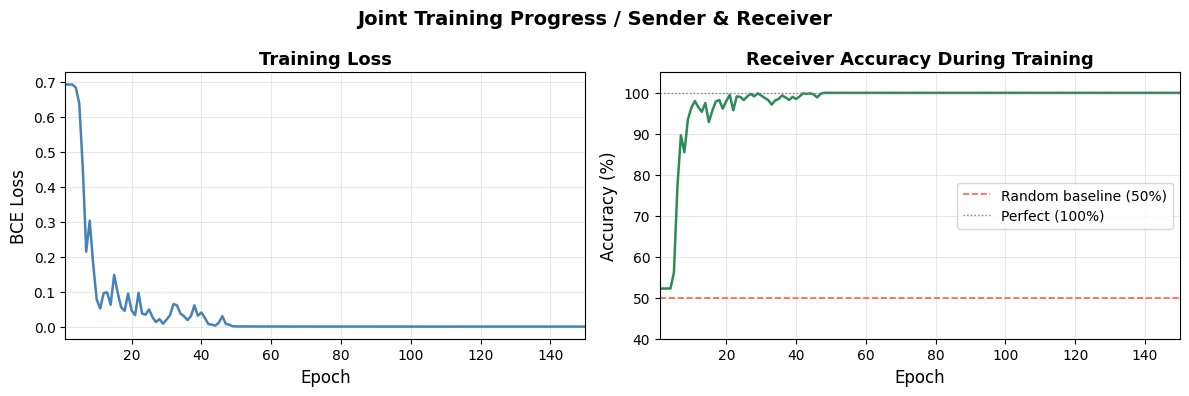

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['epoch'], history['loss'], color='steelblue', linewidth=1.8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('BCE Loss', fontsize=12)
ax1.set_title('Training Loss', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3); ax1.set_xlim(1, NUM_EPOCHS)

ax2.plot(history['epoch'], history['acc'], color='seagreen', linewidth=1.8)
ax2.axhline(50, color='tomato', linestyle='--', linewidth=1.2, label='Random baseline (50%)')
ax2.axhline(100, color='gray', linestyle=':', linewidth=1.0, label='Perfect (100%)')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Receiver Accuracy During Training', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)
ax2.set_xlim(1, NUM_EPOCHS); ax2.set_ylim(40, 105)

plt.suptitle('Joint Training Progress / Sender & Receiver', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [8]:
# threshold at 0.5
sender.eval(); receiver.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for s_input, r_input, labels in loader:
        s_input = s_input.to(DEVICE)
        r_input = r_input.to(DEVICE)

        soft_msg  = sender(s_input)
        hard_msg  = (soft_msg >= 0.5).float()   # true binary: 0 or 1

        pred = receiver(r_input, hard_msg)
        predicted = (pred.squeeze(1) >= 0.5).float()

        all_preds.append(predicted.cpu())
        all_labels.append(labels)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

accuracy   = (all_preds == all_labels).float().mean().item() * 100
error_rate = 100 - accuracy

# Message distribution: how often does S send 0 vs 1?
msg_mean = all_preds.mean().item()

results = pd.DataFrame({
    'Metric': ['Total pairs evaluated', 'Correct predictions',
               'Accuracy (%)', 'Error rate (%)', 'Random baseline accuracy (%)'],
    'Value':  [len(all_labels), int((all_preds == all_labels).sum()),
               f'{accuracy:.2f}', f'{error_rate:.2f}', '50.00']
})
print('=== Final Evaluation (hard binary message) ===')
print(results.to_string(index=False))
results

=== Final Evaluation (hard binary message) ===
                      Metric Value
       Total pairs evaluated   800
         Correct predictions   794
                Accuracy (%) 99.25
              Error rate (%)  0.75
Random baseline accuracy (%) 50.00


,Metric,Value
0,Total pairs evaluated,800
1,Correct predictions,794
2,Accuracy (%),99.25
3,Error rate (%),0.75
4,Random baseline accuracy (%),50.00


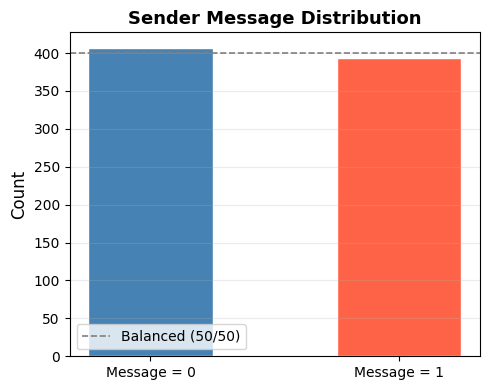

Message 0: 407 (50.9%)   Message 1: 393 (49.1%)


In [9]:
sender.eval()
messages = []
with torch.no_grad():
    for s_input, _, _ in loader:
        s_input = s_input.to(DEVICE)
        soft = sender(s_input)
        hard = (soft >= 0.5).float()
        messages.append(hard.squeeze(1).cpu())

messages = torch.cat(messages)
n_zeros = (messages == 0).sum().item()
n_ones  = (messages == 1).sum().item()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Message = 0', 'Message = 1'], [n_zeros, n_ones],
       color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Sender Message Distribution', fontsize=13, fontweight='bold')
ax.axhline(len(messages)/2, color='gray', linestyle='--',
           linewidth=1.2, label='Balanced (50/50)')
ax.legend(fontsize=10); ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout(); plt.show()
print(f'Message 0: {n_zeros} ({100*n_zeros/len(messages):.1f}%)   '
      f'Message 1: {n_ones} ({100*n_ones/len(messages):.1f}%)')

## Analysis and Discussion

### Is the task even doable?

Honestly when I first read this task I wasn't sure it was possible, compressing
the order of two images into a single 0 or 1 feels like throwing away almost all
the information. But looking at the results, it clearly works and works really well.

### What actually happened during training

The results were better than I expected. By epoch 10 the receiver was already
at 96.4% accuracy, and by epoch 50 it hit 100% and stayed there for the rest of
training. The loss basically dropped to zero. So the two models figured out a
working communication protocol very quickly.

The final evaluation with the hard binary message (hard 0 or 1 instead of the
soft value used during training) gave 99.25% accuracy, only 6 pairs out of 800
were wrong. That is a 0.75% error rate compared to the 50% you'd get from random
guessing. That gap is huge and tells us the protocol is very real and not noise.

One thing I found really interesting is the message distribution, the sender
used message 0 exactly 407 times (50.9%) and message 1 exactly 393 times (49.1%).
That is almost perfectly balanced, which means the sender learned a fair and
consistent rule rather than just always outputting the same bit.

### What the models probably learned

I think the sender learned some asymmetric scoring of the two images, something
like "compare a learned feature of the top image vs the bottom image, output 1 if
top scores higher." It doesn't matter what the exact feature is as long as it is
consistent. The receiver then uses the same logic to compare its own input against
the message. This kind of thing reminded me of my bachelor's work in computer
vision where CNNs would learn to rank or compare visual inputs, seeing it emerge
here from just a 1-bit bottleneck was genuinely satisfying.

### Where it can still fail

The 6 wrong predictions are interesting. With only 1 bit and 100 images, some
pairs are probably just hard, maybe two very similar images where the sender's
scoring function is not confident enough and lands on the wrong side of the 0.5
threshold. Also the small training set of 100 images means the models might be
partly memorising specific pairs rather than learning a fully general rule. If
you tested on completely new images the accuracy would probably drop.

### Overall

I really enjoyed this task. It felt less like a standard classification problem
and more like designing a tiny communication system, which I hadn't thought about
since my computer vision courses and one project in undergrad. Watching accuracy jump from 52% at
epoch 1 to 100% by epoch 50, and knowing that two separate networks figured out
how to talk to each other using just one bit, was one of those moments that
reminded me why I found this field so exciting in the first place.